<a href="https://colab.research.google.com/github/prathyushkumarreddy/all-tasks/blob/main/typesofbraintumor_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

In [ ]:
import pickle

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import cv2
import os
import random
import matplotlib.pyplot as plt

In [ ]:
DIRECTORY = "/content/brain-tumor-classification-mri/Training"
categories = ["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]

glioma_tumor: 0
meningioma_tumor: 1
no_tumor: 2
pituitary_tumor: 3


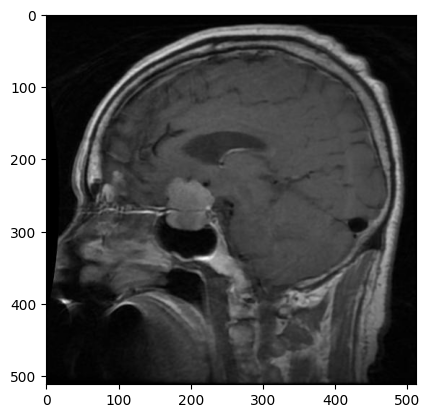

In [ ]:

IMAGE_SIZE = 255
data = []

for category in categories:
  folders = os.path.join(DIRECTORY,category)
  label = categories.index(category)
  print(f"{category}:",label)

  for img in os.listdir(folders):
    img_path = os.path.join(folders,img)
    img_arr = cv2.imread(img_path)
    img_arr_resize = cv2.resize(img_arr,(IMAGE_SIZE,IMAGE_SIZE))
    plt.imshow(img_arr)
    #break
    data.append([img_arr_resize,label])



In [ ]:
len(data)

2870

In [ ]:
random.shuffle(data)

In [ ]:
data[0]

[array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], dtype=uint8),
 2]

In [ ]:
x= []
y =[]
for features,labels in data:
  x.append(features)
  y.append(labels)


In [ ]:
len(x)

2870

In [ ]:
len(y)

2870

In [ ]:
y

[2,
 3,
 3,
 1,
 1,
 0,
 0,
 3,
 3,
 1,
 0,
 0,
 1,
 1,
 3,
 3,
 0,
 1,
 2,
 1,
 2,
 1,
 2,
 0,
 3,
 0,
 3,
 1,
 2,
 1,
 0,
 0,
 3,
 3,
 0,
 1,
 3,
 3,
 2,
 3,
 1,
 3,
 0,
 2,
 3,
 0,
 3,
 3,
 0,
 1,
 1,
 0,
 1,
 3,
 3,
 0,
 3,
 0,
 0,
 0,
 1,
 2,
 1,
 3,
 2,
 1,
 1,
 0,
 1,
 3,
 3,
 1,
 2,
 0,
 1,
 3,
 0,
 3,
 0,
 1,
 1,
 3,
 0,
 3,
 0,
 1,
 3,
 3,
 0,
 2,
 3,
 1,
 3,
 0,
 0,
 0,
 1,
 3,
 3,
 3,
 3,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 2,
 3,
 3,
 0,
 1,
 3,
 1,
 3,
 2,
 3,
 1,
 2,
 0,
 1,
 3,
 3,
 3,
 3,
 2,
 0,
 0,
 3,
 1,
 0,
 3,
 3,
 1,
 1,
 1,
 3,
 3,
 0,
 3,
 1,
 0,
 0,
 1,
 0,
 0,
 3,
 3,
 1,
 1,
 3,
 3,
 3,
 2,
 1,
 0,
 1,
 1,
 0,
 3,
 0,
 3,
 0,
 0,
 1,
 0,
 3,
 3,
 1,
 3,
 1,
 3,
 0,
 0,
 2,
 3,
 0,
 2,
 0,
 2,
 1,
 3,
 1,
 0,
 3,
 2,
 0,
 3,
 1,
 3,
 0,
 2,
 0,
 2,
 2,
 0,
 2,
 3,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 2,
 1,
 3,
 2,
 3,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 2,
 1,
 1,
 0,
 0,
 3,
 2,
 3,
 2,
 1,
 2,
 0,
 0,
 1,
 2,
 0,
 1,
 3,
 3,
 3,
 2,
 1,
 3,


In [ ]:
# creating it into array format
x = np.array(x)
y = np.array(y)

In [ ]:
x.shape

(2870, 255, 255, 3)

In [ ]:
y.shape

(2870,)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [ ]:
import tensorflow as tf

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Dropout

In [ ]:
from keras.layers import Flatten,Dense

In [ ]:
cnn = Sequential()
cnn.add(Conv2D(filters=64,kernel_size=(3,3),padding="same",activation="relu",input_shape=(255,255,3)))
cnn.add(MaxPooling2D(1,1))
cnn.add(Conv2D(filters=32,kernel_size=(3,3),padding="same",activation="relu"))
cnn.add(MaxPooling2D(1,1))
cnn.add(Dropout(0.2))
cnn.add(Conv2D(filters=32,kernel_size=(2,2),padding="same",activation="relu"))
cnn.add(MaxPooling2D(2,2))
cnn.add(Conv2D(filters=32,kernel_size=(2,2),padding="same",activation="relu"))
cnn.add(MaxPooling2D(2,2))
cnn.add(Dropout(0.2))
cnn.add(Conv2D(filters=128,kernel_size=(1,1),padding="same",activation="relu"))
cnn.add(MaxPooling2D(2,2))
cnn.add(Conv2D(filters=128,kernel_size=(1,1),padding="same",activation="relu"))
cnn.add(MaxPooling2D(2,2))
cnn.add(Dropout(0.2))

cnn.add(Flatten())
cnn.add(Dense(512,activation="relu"))
cnn.add(Dense(300,activation="relu"))
cnn.add(Dense(200,activation="relu"))
cnn.add(Dense(4,activation="softmax"))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 255, 255, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 255, 255, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 255, 255, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 255, 255, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 127, 127, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 63, 63, 128)    │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 31, 31, 128)    │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    14,746,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 300)            │       153,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,010,264 (57.26 MB)

 Trainable params: 15,010,264 (57.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

In [ ]:
history = cnn.fit(x_train,y_train,epochs=10,validation_split=0.1)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 25s 283ms/step - accuracy: 0.3770 - loss: 12.4267 - val_accuracy: 0.4826 - val_loss: 1.1869
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 31s 187ms/step - accuracy: 0.5575 - loss: 1.0351 - val_accuracy: 0.6261 - val_loss: 0.9424
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.6331 - loss: 0.8262 - val_accuracy: 0.6391 - val_loss: 0.7677
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.7076 - loss: 0.6489 - val_accuracy: 0.6739 - val_loss: 0.7284
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.7493 - loss: 0.5530 - val_accuracy: 0.7783 - val_loss: 0.5599
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.8378 - loss: 0.3941 - val_accuracy: 0.7391 - val_loss: 0.6340
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 12s 187ms/step - accuracy: 0.8792 - loss: 0.3033 - val_accuracy: 0.7391 - val_loss: 0.6040
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 187ms/step - accuracy: 0.8780 - loss: 0.2819 - val_acc

In [ ]:
loss,accuracy = cnn.evaluate(x_test,y_test)
print("Test accuracy:",accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.8052 - loss: 0.4933
Test accuracy: 0.7979093790054321


In [ ]:
pred=cnn.predict(x_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


In [ ]:
pred

array([[5.0257694e-02, 6.8523526e-02, 1.3332831e-02, 8.6788595e-01],
       [9.4516248e-01, 5.4349236e-02, 2.5881190e-04, 2.2943156e-04],
       [1.9115397e-03, 6.3447217e-03, 8.3409337e-04, 9.9090964e-01],
       ...,
       [6.9791740e-03, 4.3104091e-03, 1.5202499e-05, 9.8869520e-01],
       [8.2914603e-01, 1.7043595e-01, 3.0685717e-04, 1.1111007e-04],
       [8.1152576e-01, 1.5514809e-01, 8.5148811e-03, 2.4811251e-02]],
      dtype=float32)

In [ ]:
index=[np.argmax(i) for i in pred]

In [ ]:
new_dataframe = pd.DataFrame({"actual":y_test,"predict":index})
print(new_dataframe)

     actual  predict
0         3        3
1         0        1
2         3        0
3         0        0
4         1        3
..      ...      ...
569       2        0
570       1        3
571       3        0
572       1        1
573       1        0

[574 rows x 2 columns]


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(y_test,index))

              precision    recall  f1-score   support

           0       0.64      0.98      0.78       170
           1       0.89      0.46      0.60       155
           2       0.91      0.89      0.90        82
           3       0.95      0.88      0.92       167

    accuracy                           0.80       574
   macro avg       0.85      0.80      0.80       574
weighted avg       0.84      0.80      0.79       574



In [ ]:
import seaborn as sns

In [ ]:
cn=confusion_matrix(y_test,index)

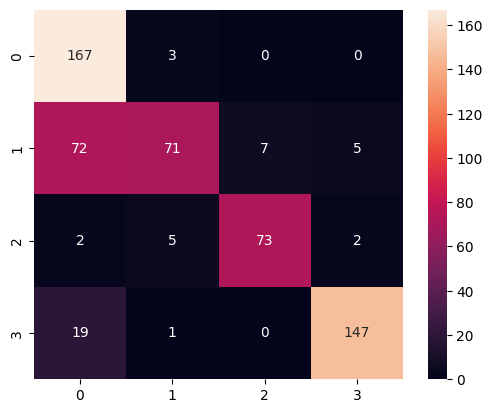

In [ ]:
sns.heatmap(cn,annot=True,square=True,fmt=".0f")
plt.show()

In [ ]:
# saving the model

In [ ]:
import seaborn as sns

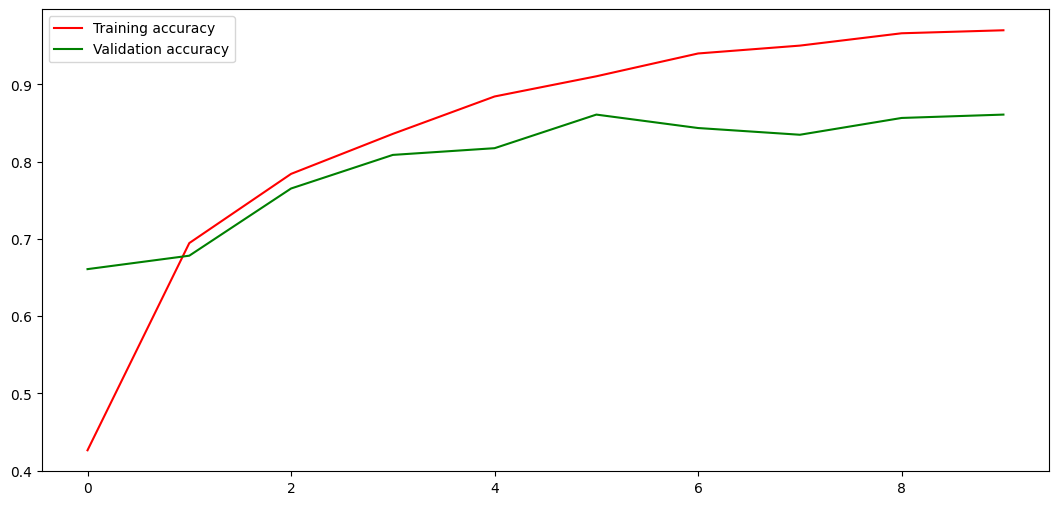

In [ ]:

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
epochs=range(len(acc))
fig = plt.figure(figsize=(13,6))
plt.plot(epochs,acc,'r',label="Training accuracy")
plt.plot(epochs,val_acc,'g',label="Validation accuracy")
plt.legend(loc="upper left")
plt.show()

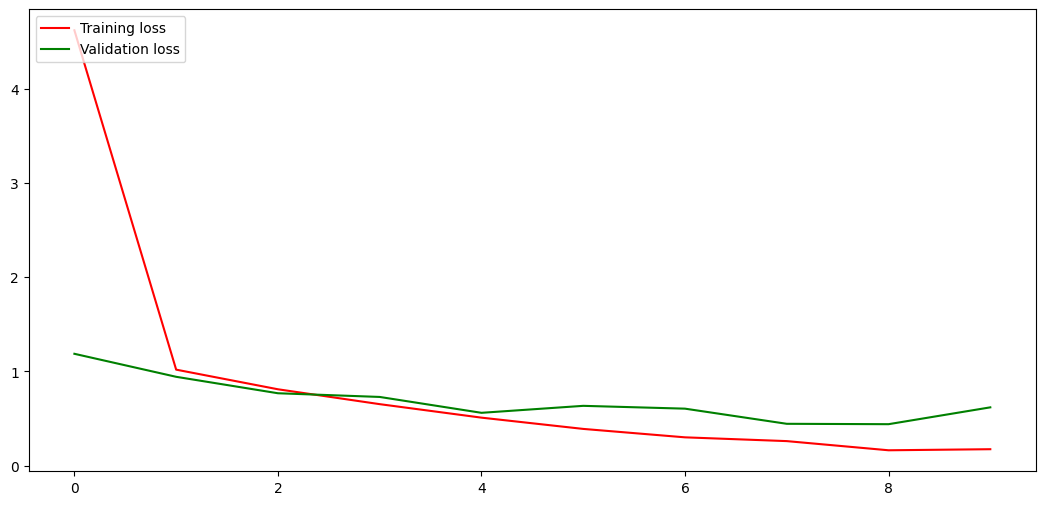

In [ ]:
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(len(loss))
fig = plt.figure(figsize=(13,6))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'g',label="Validation loss")
plt.legend(loc="upper left")
plt.show()

In [ ]:
# prediction

In [ ]:
img=cv2.imread('/content/brain-tumor-classification-mri/Testing/pituitary_tumor/image(11).jpg')
img=cv2.resize(img,(255,255))
img_array = np.array(img)
img_array = img_array.reshape(1,255,255,3)

In [ ]:
from tensorflow.keras.preprocessing import image

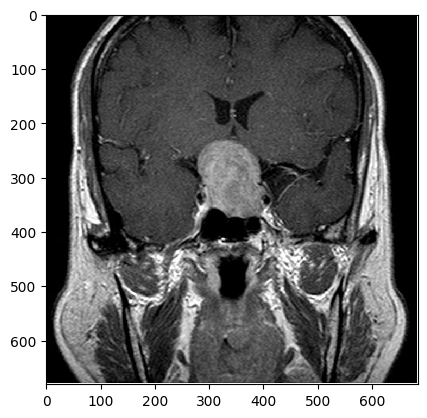

In [ ]:
img = image.load_img('/content/brain-tumor-classification-mri/Testing/pituitary_tumor/image(11).jpg')
plt.imshow(img,interpolation='nearest')
plt.show()

In [ ]:
a=cnn.predict(img_array)
indeces = a.argmax()
print(indeces)
if indeces == 0:
  print("prediction is Glioma_tumor")
elif indeces == 1:
  print("prediction is meningioma_tumor")
elif indeces ==2:
  print("prediction is No_tumor")
else:
  print("prediction is pituitary_tumor")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
3
prediction is pituitary_tumor
